# Jupyter Notebook Example
## Recovering Turning Radius From Noisy Manufactured Data
### Overview

In this Jupyter Notebook, we'll describe how the parameters of a particular data smoothing method affect its accuracy. We'll use a manufactured noisy trajectory and then try to recover the curvature of that trajectory. 

In a Jupyter Notebook, you can logically separate code blocks and Markdown blocks for clarity. Each code block can be debugged individually. Plots will be displayed in the notebook. You can use Latex in the Markdown blocks. 

In [5]:
# imports and plot parameters

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import pandas as pd

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['legend.fontsize'] = 10

### Manufactured noisy trajectory 

We begin by choosing the circle's true radius $R = 5.0$ and choosing $\sigma$ to be a normally-distributed random variable with mean 0 and standard deviation 0.1, 

\begin{align*}
\sigma &= N(0, 0.01)
\end{align*}

We then generate noisy trajectory information as

\begin{align*}
    \begin{bmatrix}x \\ y\end{bmatrix} &= \begin{bmatrix}(R + \sigma)\cos(\theta)\\
   (R + \sigma)\sin(\theta)\end{bmatrix}
\end{align*}

In [6]:
## manufactured noisy data 

# parameters
N = 1000            # number of points along the circle
R = 5.0             # base radius
theta = np.linspace(0, 2 * np.pi, N)

dth = 2 * np.pi / N
theta = np.arange(0, 2*np.pi, dth)

rng = np.random.default_rng()

x = []
y = []

for theta_inst in theta:
    sigma = rng.normal(loc=0.0, scale=0.1)
    x.append((R + sigma) * np.cos(theta_inst))
    y.append((R + sigma) * np.sin(theta_inst))

x = np.array(x)
y = np.array(y)

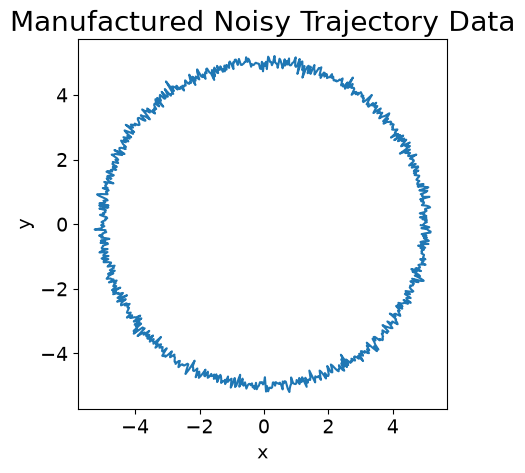

In [7]:
## plot manufactured trajectory 
plt.figure()
plt.plot(x, y)
plt.title("Manufactured Noisy Trajectory Data")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_box_aspect(1)
plt.show()

### Recovering the true radius 

Curvature is defined in terms of instantaneous velocity and acceleration as

\begin{align*}
\kappa &= \lVert \overline{\gamma''(s)} \rVert \\
&= \frac{\sqrt{\lVert\gamma'(t)\rVert^2\lVert\gamma''(t)\rVert - \left(\gamma'(t)\cdot \gamma''(t)\right)^2}}{\lVert\gamma'(t)\rVert^3}
\end{align*}

In [8]:
# a function to calculate curvature from instantaneous velocity and acceleration

def calculate_curvature(velocity, acceleration):
    cross_product = velocity[0] * acceleration[1] - velocity[1] * acceleration[0]
    speed_cubed = (np.linalg.norm(velocity)) ** 3
    curvature = np.abs(cross_product) / speed_cubed
    return curvature

### Error

Now we're ready to characterize the accuracy of our method. We're interested in the relationship between the window size of our smoothing filter and how well the true radius is recovered from the noisy data. Error is given by 
\begin{align*}
\text{Err} &= \frac{|\overline{R}_\text{computed} - R_\text{true}|}{R_\text{true}}
\end{align*}

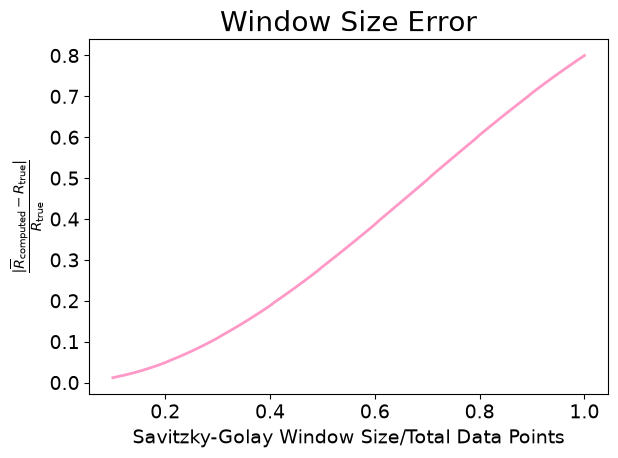

In [12]:
errors = []
window_sizes = np.linspace(100, N, 100)

for window_size in window_sizes:
    
    # velocities from trajectory
    dy = savgol_filter(y, window_length=window_size, polyorder=2, deriv=1, delta=1.0, mode='wrap')
    dx = savgol_filter(x, window_length=window_size, polyorder=2, deriv=1, delta=1.0, mode='wrap')
    ddy = savgol_filter(y, window_length=window_size, polyorder=2, deriv=2, delta=1.0, mode='wrap')
    ddx = savgol_filter(x, window_length=window_size, polyorder=2, deriv=2, delta=1.0, mode='wrap')

    curvature_array = np.zeros_like(theta)

    for index, val in enumerate(theta):
        velocity_head_current = np.zeros(2)
        acceleration_head = np.zeros(2)
        velocity_head_current[0] = dx[index]
        velocity_head_current[1] = dy[index]
        acceleration_head[0] = ddx[index]
        acceleration_head[1] = ddy[index]
    
        # instantaneous curvature from instantaneous velocity and acceleration
        curvature_array[index] = calculate_curvature(velocity_head_current, acceleration_head)

    # average curvature, moving mean 
    df = pd.DataFrame({'Index': range(index + 1), 'Value': curvature_array})
    df.set_index('Index', inplace=True)
    avg_window = 10
    df['SMA'] = df['Value'].rolling(window=avg_window).mean()
    sma_mean = df['SMA'].mean()
    R_computed = 1 / sma_mean

    errors.append(np.abs(R_computed - R) / R)

plt.plot(window_sizes / N, errors, label='Error',  color=[1.0, 0.0, 0.45], linewidth=2, alpha=0.4)
plt.xlabel("Savitzky-Golay Window Size/Total Data Points")
plt.ylabel(r'$\frac{|\overline{R}_\text{computed} - R_\text{true}|}{R_\text{true}}$')
plt.title('Window Size Error')
plt.tight_layout()
